In [ ]:
import os

import pandas as pd
import sankey_diag

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
prostate_response = pd.read_csv('/mnt/disks/pancan/pnet_database/prostate/processed/response_paper.csv')
prostate_response.rename(columns={'id': "Tumor_Sample_Barcode"}, inplace=True)
prostate_response.set_index('Tumor_Sample_Barcode', inplace=True)

In [ ]:
def load_importance_scores(results_dir):
    layer_list = [x for x in os.listdir(results_dir) if x[-3:] == 'csv' and x[:5] == 'layer']
    layer_list = ['gene_feature', 'gene'] + sorted(['_'.join(x.split('_')[:-1]) for x in layer_list])

    all_imps = pd.DataFrame(columns=['Importance', 'Layer'])
    for l in layer_list:
        df_imps = pd.DataFrame(columns=['Importance', 'Layer'])
        imps = pd.read_csv(f'{results_dir}{l}_importances.csv').set_index('Unnamed: 0')
        df_imps = imps.reset_index().melt(id_vars='Unnamed: 0', var_name='Gene/Pathway', value_name='Importance').rename(columns={'Unnamed: 0': 'Sample'})
        df_imps['Layer'] = l
        all_imps = pd.concat([all_imps, df_imps])
    return all_imps

In [14]:
all_imps0 = load_importance_scores('/mnt/disks/pancan/pnet/results/prostate_val/run0/')
all_imps0['Run'] = 0
all_imps1 = load_importance_scores('/mnt/disks/pancan/pnet/results/prostate_val/run1/')
all_imps1['Run'] = 1

In [17]:
all_imps0

,Importance,Layer,Sample,Gene/Pathway,Run
0,-0.000000,gene_feature,TCGA-HC-8264,SDHA_mut,0
1,-0.000000,gene_feature,TCGA-V1-A8MJ,SDHA_mut,0
2,-0.000000,gene_feature,TCGA-EJ-7123,SDHA_mut,0
3,-0.000000,gene_feature,05-221MM1_BONE,SDHA_mut,0
4,-0.000000,gene_feature,SC_9091,SDHA_mut,0
...,...,...,...,...,...
2953,0.000000,layer_4,TCGA-G9-6336,Signal Transduction,0
2954,0.115266,layer_4,AAPC-STID0000021594-Tumor-SM-3RVWJ,Signal Transduction,0
2955,0.272371,layer_4,SC_9105,Signal Transduction,0
2956,0.000000,layer_4,TCGA-EJ-A65B,Signal Transduction,0


In [18]:
pd.concat([all_imps0,all_imps1])#.groupby(['Layer','Sample','Gene/Pathway']).mean()

,Importance,Layer,Sample,Gene/Pathway,Run
0,-0.000000,gene_feature,TCGA-HC-8264,SDHA_mut,0
1,-0.000000,gene_feature,TCGA-V1-A8MJ,SDHA_mut,0
2,-0.000000,gene_feature,TCGA-EJ-7123,SDHA_mut,0
3,-0.000000,gene_feature,05-221MM1_BONE,SDHA_mut,0
4,-0.000000,gene_feature,SC_9091,SDHA_mut,0
...,...,...,...,...,...
2924,0.069628,layer_4,TCGA-KK-A8IG,Signal Transduction,1
2925,-0.020168,layer_4,TCGA-XK-AAK1,Signal Transduction,1
2926,0.078213,layer_4,TCGA-HC-7211,Signal Transduction,1
2927,-0.006471,layer_4,TCGA-ZG-A9N3,Signal Transduction,1


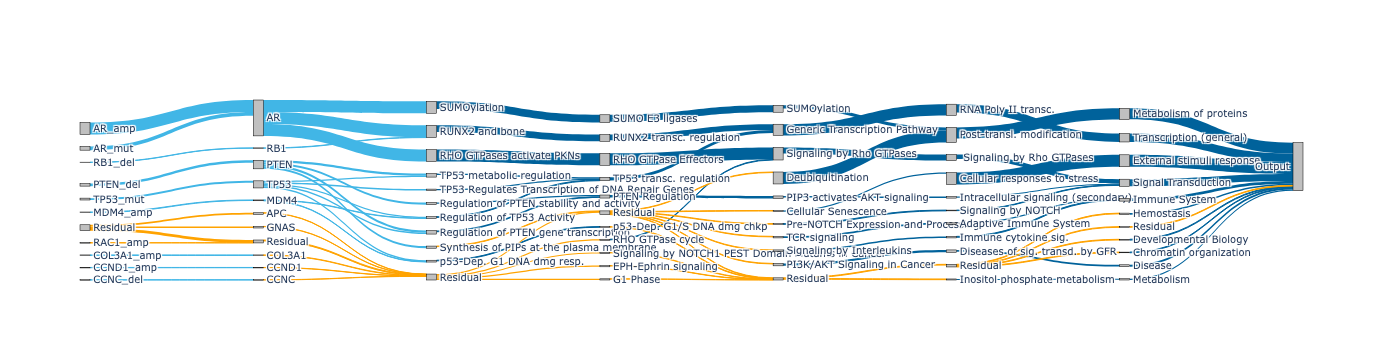

In [99]:
imps_dir = '/mnt/disks/pancan/pnet/results/prostate_val/'
savepath = '/mnt/disks/pancan/pnet/figures/prostate_sankey_diagram.html'
sk = sankey_diag.SankeyDiag(imps_dir, runs=10, target=prostate_response)
fig = sk.get_sankey_diag(savepath)

In [90]:
sk.grouped_imps['Importance'] = layer_normalized_imps

In [91]:
sk.grouped_imps

,Gene/Pathway,Layer,response,Importance,Run
0,5-Phosphoribose 1-diphosphate biosynthesis,layer_1,1,0.000000,0.040381
1,A tetrasaccharide linker sequence is required ...,layer_0,1,0.000000,0.040381
2,A1CF,gene,1,0.000566,0.040381
3,A1CF_amp,gene_feature,1,0.000391,0.040381
4,A1CF_del,gene_feature,1,0.000078,0.040381
...,...,...,...,...,...
3983,tamatinib-resistant FLT3 mutants,layer_0,1,0.000007,0.040381
3984,tandutinib-resistant FLT3 mutants,layer_0,1,0.000165,0.040381
3985,trans-Golgi Network Vesicle Budding,layer_2,1,0.000129,0.040381
3986,vRNA Synthesis,layer_0,1,0.000000,0.040381


In [76]:
sk.grouped_imps[sk.grouped_imps['Layer']=='layer_1'].iloc[613]

Gene/Pathway    RHO GTPase Effectors
Layer                        layer_1
response                           1
Importance                  0.178355
Run                         0.040381
Name: 2899, dtype: object

In [95]:
sk.grouped_imps.nlargest(20, 'Importance')

,Gene/Pathway,Layer,response,Importance,Run
88,AR,gene,1,1.388857,0.040381
118,AR_amp,gene_feature,1,1.052432,0.040381
120,AR_mut,gene_feature,1,0.329944,0.040381
2910,RHO GTPases activate PKNs,layer_0,1,0.258046,0.040381
2699,PTEN,gene,1,0.249290,0.040381
1070,Deubiquitination,layer_2,1,0.240541,0.040381
1601,Generic Transcription Pathway,layer_2,1,0.225131,0.040381
2703,PTEN_del,gene_feature,1,0.223522,0.040381
682,Cellular responses to external stimuli,layer_4,1,0.216299,0.040381
683,Cellular responses to stress,layer_3,1,0.215952,0.040381


In [62]:
sk.grouped_imps[['Importance']].apply(zscore)

,Importance
0,-0.086924
1,-0.086924
2,-0.061728
3,-0.073728
4,-0.084302
...,...
3983,-0.086869
3984,-0.085562
3985,-0.085926
3986,-0.086924


In [6]:
fig.write_image("/mnt/disks/pancan/pnet/figures/prostate_sankey_diagram.pdf")

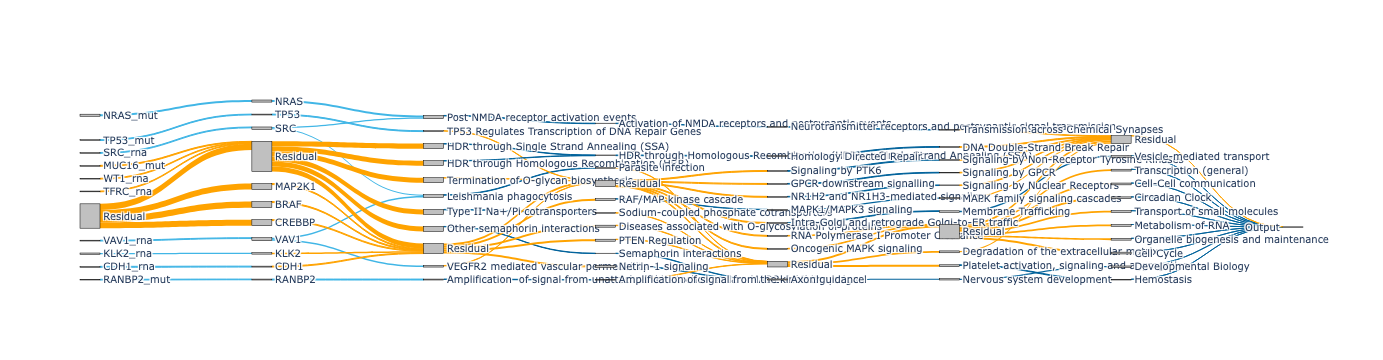

In [6]:
imps_dir = '/mnt/disks/pancan/pnet/results/ploidy/liu_val_skcm/run1/'
savepath = '/mnt/disks/pancan/pnet/figures/ploidy_liu_sankey_diagram.html'
sk = sankey_diag.SankeyDiag(imps_dir)
fig = sk.get_sankey_diag(savepath)

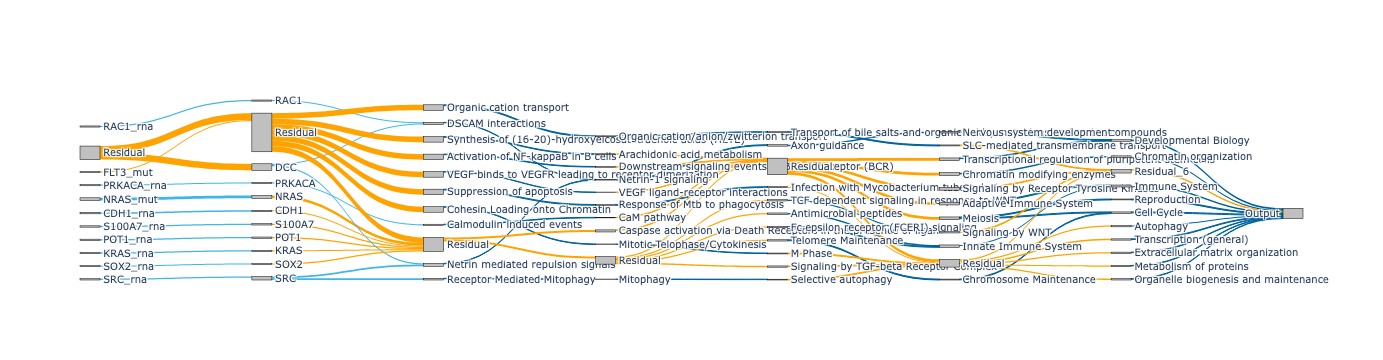

In [46]:
imps_dir = '/mnt/disks/pancan/pnet/results/ploidy/tcga_skcm/run0/'
savepath = '/mnt/disks/pancan/pnet/figures/ploidy_tcga_sankey_diagram.html'
sk = sankey_diag.SankeyDiag(imps_dir)
fig = sk.get_sankey_diag(savepath)

In [ ]:
from xhtml2pdf import pisa  # import python module


# Utility function
def convert_html_to_pdf(source_html, output_filename):
    # open output file for writing (truncated binary)
    result_file = open(output_filename, "w+b")

    # convert HTML to PDF
    pisa_status = pisa.CreatePDF(
            source_html,                # the HTML to convert
            dest=result_file)           # file handle to recieve result

    # close output file
    result_file.close()                 # close output file

    # return True on success and False on errors
    return pisa_status.err